# Hamilton (1989) Forward Filter

In order to find expansion/recession probabilities over time, we will use Hamilton's 2 state model, his MLE's for the parameters of the normally distributed GDP growth under each state.


| Parameter | Value |
|-----------|-------|
| $\mu_0$ (expansion) | 3.87902 |
| $\mu_1$ (recession) | -1.51768 |
| $\sigma$ | $\sqrt{10.18}$ |
| $p_{00}$ | 0.943698 |
| $p_{11}$ | 0.696427 |

Initial state vector: $ x_0 = [0.8, 0.2]$

## The Filter

**Step 1 — Prediction**

$$\underline{\hat{x_t}} = \underline{x_{t-1}} \, P$$

**Step 2 — Update**

$$\underline{x_t} = \frac{\underline{w_t} \, \underline{\hat{x_t}}}{f(y_t)}$$

here $f(y_t) = \sum_{j} f(y_t \mid s_t = j) \, \hat{x}_{t,j}$ is the marginal density of $y_t$ by the law of total probability.

Where $\underline{w_t} = [f(y_t \mid s_t = 0),\ f(y_t \mid s_t = 1)]$ is the vector of state-conditional densities. The denominator is just the sum of the vector entries, normalising so probabilities sum to 1.

Initial goal: Replicate Hamilton's result that we are able to declare that the economy was in a recession during Quarter x faster than the NBER. We will check how reliable this is depending on level of data revision. Using only GDP data!

## Using revised GDP estimates 

We use the FRED "Percent Change from Preceding Period, Quarterly, Seasonally Adjusted Annual Rate (Q2 1947 to Q1 2026)" which updates at any point the GDP growth is revised, not very useful for live trading and decision making but is a baseline.

Recall we have 3 GDP estimates per quarter:
Advance estimate: approx. 30 days after quarter end
Revision: approx. 60 days after quarter end
Final estimate: approx. 90 days after quarter end

We will use the rule: if P(recession) >= 0.67 declare recession and end when <= 0.33
Hamilton includes that we start the recession (when backward smoothing using all available data) on the first quarter when probability of recession was over 50% looking back from the first quarter with over 67%. Then to declare end of recession we look back from first quarter when recession probability is less than 0.33, to find quarter where recession probability is less than 0.5 and this is recession ending.
We will omit this and just consier the 0.67/0.33 rule to start.

Recall this is using quarter t+1 data release to predict quarter t.
If we want to implement into trading we need this to be correctly predicted i.e. 30 days into quarter t we get t-1. Then we use our transition matrix to estimate t, so it seems we get 2 months of "trading" advantage (irrelevant for now).

Atlanta Fed GDPNow will be better.

            p_expansion  p_recession  recession_call
date                                                
1947-04-01     0.582068     0.417932               0
1947-07-01     0.422191     0.577809               0
1947-10-01     0.955400     0.044600               0
1948-01-01     0.993562     0.006438               0
1948-04-01     0.996741     0.003259               0
1948-07-01     0.966878     0.033122               0
1948-10-01     0.892440     0.107560               0
1949-01-01     0.175941     0.824059               1
1949-04-01     0.153620     0.846380               1
1949-07-01     0.769078     0.230922               0


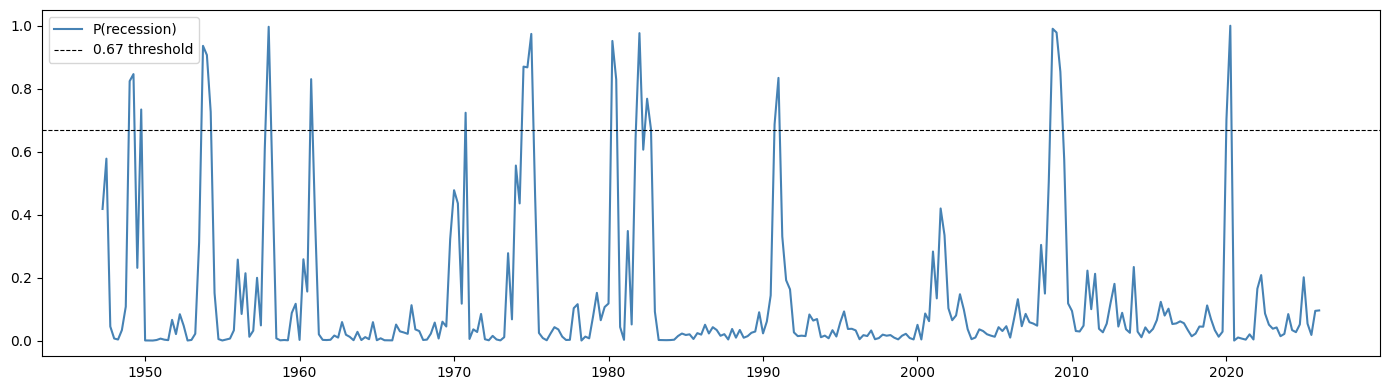

In [22]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# load data
gdp = pd.read_csv('data/gdp_growth.csv', index_col=0, parse_dates=True).squeeze()

mu = [3.87902, -1.51768]
sigma = np.sqrt(10.1800)
P = np.array([[0.943698, 0.056302],
              [0.303573, 0.696427]])

# initial state vector [expansion, recession]
x = np.array([0.8, 0.2])

# store results
results = []

for date, yt in gdp.items():
    # step 1 - prediction
    x_hat = x @ P
    
    # step 2 - densities
    w = np.array([norm.pdf(yt, mu[0], sigma),
                  norm.pdf(yt, mu[1], sigma)])
    
    # step 3 - update
    numerator = w * x_hat
    x = numerator / numerator.sum()
    
    results.append({'date': date,
                    'p_expansion': x[0],
                    'p_recession': x[1]})

df = pd.DataFrame(results).set_index('date')

#create a binary indicator column = 1 if P(Recession) >= 0.67 
df['recession_call'] = (df['p_recession'] > 0.67).astype(int)
print(df.head(10))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['p_recession'], color='steelblue', label='P(recession)')
ax.axhline(0.67, color='black', linewidth=0.8, linestyle='--', label='0.67 threshold')
ax.legend()
plt.tight_layout()
plt.show()


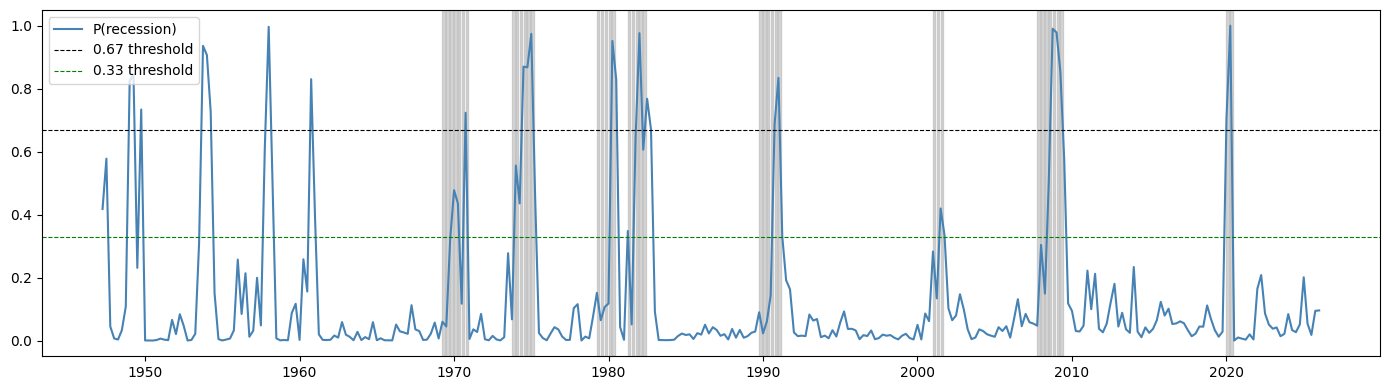

In [25]:
#compare to Hamiltons findings which run backward smoothing 
#ONLY FROM 1967 Q4! (as this is start of NBER dates)

nber = pd.read_csv('data/nber.csv', index_col=0, parse_dates=True).squeeze()

#create column using nber.csv to view actual recessions
df['nber'] = nber
#Now plot our recession probabilities against the true announced recession
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['p_recession'], color='steelblue', label='P(recession)')
ax.axhline(0.67, color='black', linewidth=0.8, linestyle='--', label='0.67 threshold')
ax.axhline(0.33, color='green', linewidth=0.8, linestyle='--', label='0.33 threshold')

for date in nber[nber == 1].index:
    ax.axvspan(date, date + pd.offsets.QuarterBegin(), color='grey', alpha=0.3)

ax.legend()
plt.tight_layout()
plt.show()

# Results

We observe that only using the forward filter misses the start of many recessions or entirely. We completely miss the 2001 recession as it was mild and short. 

As the goal is to implement this idea towards trading, there is no need to look at backward smoothing.
The clear next step is to use higher frequency data and redefine our transition matrix and parameters.